# EDA de 20 Newsgroups para Topic Modeling

Este notebook realiza un EDA del dataset 20 Newsgroups orientado al modulo de topic extraction de documentos.

Objetivos:
- Revisar calidad, longitud y distribucion de clases.
- Analizar terminos y representaciones BoW/TF-IDF.
- Definir y exportar un subconjunto de categorias para experimentacion de topic modeling.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 140)

In [2]:
# Resolver root y preparar carpetas de salida
CANDIDATE_ROOT = Path.cwd().resolve()
ROOT = next(
    (p for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents] if (p / "validation").exists()),
    CANDIDATE_ROOT,
)

EDA_DIR = ROOT / "validation" / "results" / "newsgroups20_eda"
TABLES_DIR = EDA_DIR / "tables"
FIGURES_DIR = EDA_DIR / "figures"
for p in [EDA_DIR, TABLES_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Resultados EDA: {EDA_DIR}")

ROOT: /home/gabriel/clase/TFG/TFG-Chatbot
Resultados EDA: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_eda


In [3]:
# Carga de 20 Newsgroups completo
train = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
test = fetch_20newsgroups(subset="test", remove=("headers", "footers", "quotes"))

texts = train.data + test.data
targets = np.concatenate([train.target, test.target])
target_names = train.target_names

df = pd.DataFrame({
    "text": [str(t) for t in texts],
    "label_id": targets.astype(int),
})
df["label"] = df["label_id"].map(lambda idx: target_names[idx])

# Limpieza basica coherente con notebooks de validation
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 0].drop_duplicates(subset=["text"]).reset_index(drop=True)

print(df.shape)
print("Labels unicas:", df["label"].nunique())
df.head()

(18262, 3)
Labels unicas: 20


,text,label_id,label
0,"I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from t...",7,rec.autos
1,A fair number of brave souls who upgraded their SI clock oscillator have\nshared their experiences for this poll. Please send a brief me...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the ghost this weekend after\nstarting life as a 512k way back in 1985. sooo, i'm in the market...",4,comp.sys.mac.hardware
3,Do you have Weitek's address/phone number? I'd like to get some information\nabout this chip.,1,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by tombaker@world.std.com (Tom A Baker):\n\n\nMy understanding is that the 'expected errors' ar...",14,sci.space


In [4]:
# Exportar todos los documentos
documents_path = TABLES_DIR / "newsgroups20_all_documents.csv"
df[["text", "label", "label_id"]].rename(columns={"text": "document"}).to_csv(
    documents_path, index=False, encoding="utf-8"
)

print(f"Archivo generado: {documents_path}")
df[["text", "label"]].head()

Archivo generado: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_eda/tables/newsgroups20_all_documents.csv


,text,label
0,"I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from t...",rec.autos
1,A fair number of brave souls who upgraded their SI clock oscillator have\nshared their experiences for this poll. Please send a brief me...,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the ghost this weekend after\nstarting life as a 512k way back in 1985. sooo, i'm in the market...",comp.sys.mac.hardware
3,Do you have Weitek's address/phone number? I'd like to get some information\nabout this chip.,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by tombaker@world.std.com (Tom A Baker):\n\n\nMy understanding is that the 'expected errors' ar...",sci.space


In [5]:
# Calidad basica
quality = {
    "n_rows": len(df),
    "n_labels": int(df["label"].nunique()),
    "n_missing_text": int(df["text"].isna().sum()),
    "n_empty_or_blank": int((df["text"].str.strip().str.len() == 0).sum()),
    "n_duplicates_exact": int(df.duplicated(subset=["text"]).sum()),
    "dup_rate": float(df.duplicated(subset=["text"]).mean()),
}

df_quality = pd.DataFrame([quality])
df_quality.to_csv(TABLES_DIR / "quality_summary.csv", index=False)
df_quality

,n_rows,n_labels,n_missing_text,n_empty_or_blank,n_duplicates_exact,dup_rate
0,18262,20,0,0,0,0.0


In [6]:
# Longitud en caracteres y tokens
token_pattern = re.compile(r"\w+", flags=re.UNICODE)
df["char_len"] = df["text"].str.len()
df["tok_len"] = df["text"].apply(lambda t: len(token_pattern.findall(t.lower())))

desc = df[["char_len", "tok_len"]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).T
desc.to_csv(TABLES_DIR / "length_describe.csv")
desc

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
char_len,18262.0,1200.646041,3911.171957,1.0,128.0,250.0,503.0,1000.0,2013.0,3475.95,158787.0
tok_len,18262.0,208.453236,748.697129,0.0,23.0,45.0,89.0,175.0,348.9,587.00,39551.0


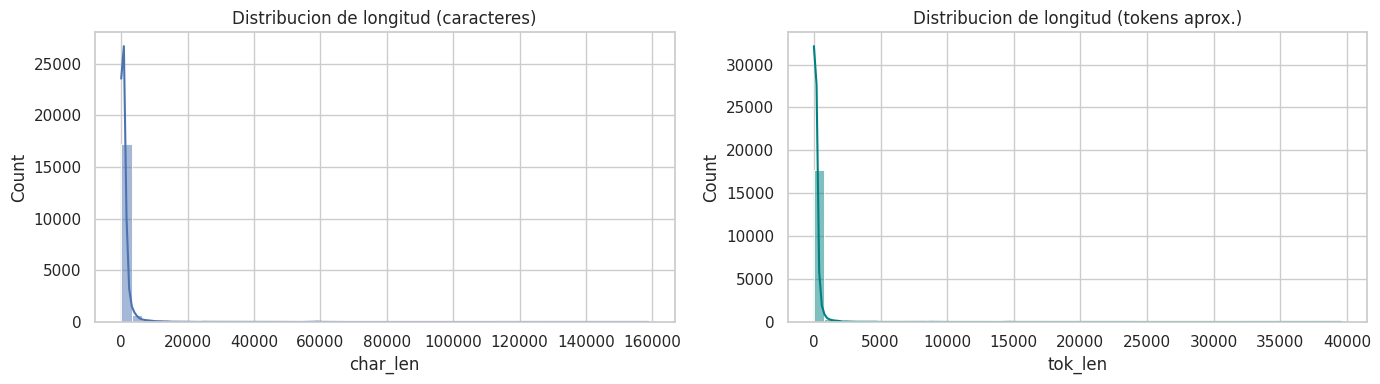

In [7]:
# Distribuciones de longitud
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["char_len"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribucion de longitud (caracteres)")

sns.histplot(df["tok_len"], bins=50, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Distribucion de longitud (tokens aprox.)")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "length_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

/tmp/ipykernel_365701/1307730850.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="count", y="label", ax=ax, palette="viridis")


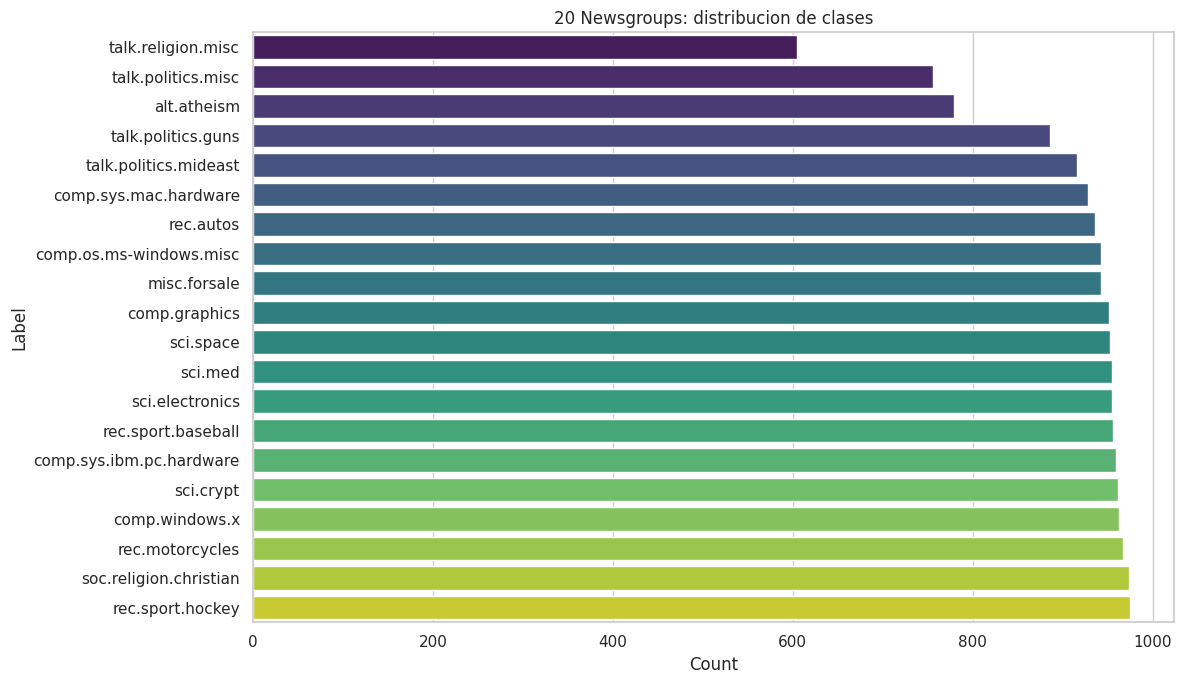

,label,count
0,rec.sport.hockey,975
1,soc.religion.christian,974
2,rec.motorcycles,967
3,comp.windows.x,963
4,sci.crypt,962
5,comp.sys.ibm.pc.hardware,959
6,rec.sport.baseball,956
7,sci.med,955
8,sci.electronics,955
9,sci.space,953


In [8]:
# Distribucion de labels
label_counts = df["label"].value_counts().rename_axis("label").reset_index(name="count")
label_counts.to_csv(TABLES_DIR / "label_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 7))
plot_df = label_counts.sort_values("count", ascending=True)
sns.barplot(data=plot_df, x="count", y="label", ax=ax, palette="viridis")
ax.set_title("20 Newsgroups: distribucion de clases")
ax.set_xlabel("Count")
ax.set_ylabel("Label")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "label_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

label_counts

/tmp/ipykernel_365701/3302409392.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=per_label_len, x="mean", y="label", ax=ax, palette="magma")


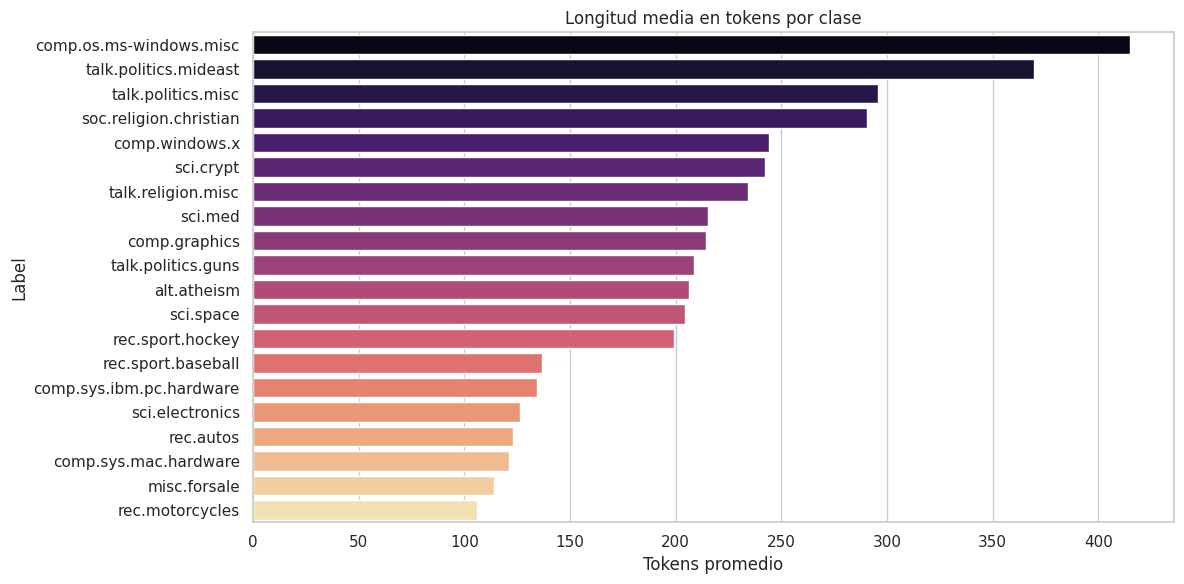

,label,count,mean,median,std
2,comp.os.ms-windows.misc,943,415.000000,75.0,2283.804557
17,talk.politics.mideast,916,369.575328,141.5,856.994706
18,talk.politics.misc,756,295.560847,116.0,792.695181
15,soc.religion.christian,974,290.458932,161.0,411.899974
5,comp.windows.x,963,243.919003,84.0,962.101913
11,sci.crypt,962,242.151767,114.0,608.515079
19,talk.religion.misc,605,234.287603,93.0,496.305977
13,sci.med,955,215.025131,98.0,500.071527
1,comp.graphics,951,214.286015,68.0,905.780829
16,talk.politics.guns,886,208.791196,103.0,491.269298


In [9]:
# Longitud media por clase
per_label_len = (
    df.groupby("label")["tok_len"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
    .sort_values("mean", ascending=False)
)
per_label_len.to_csv(TABLES_DIR / "label_length_stats.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=per_label_len, x="mean", y="label", ax=ax, palette="magma")
ax.set_title("Longitud media en tokens por clase")
ax.set_xlabel("Tokens promedio")
ax.set_ylabel("Label")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "label_mean_token_length.png", dpi=180, bbox_inches="tight")
plt.show()

per_label_len.head(10)

In [10]:
# Frecuencias de terminos
texts = df["text"].tolist()

cv_uni = CountVectorizer(stop_words="english", ngram_range=(1, 1), min_df=5, max_df=0.9)
X_uni = cv_uni.fit_transform(texts)
freq_uni = np.asarray(X_uni.sum(axis=0)).ravel()
top_uni_idx = np.argsort(freq_uni)[::-1][:40]
df_top_uni = pd.DataFrame({
    "term": np.array(cv_uni.get_feature_names_out())[top_uni_idx],
    "count": freq_uni[top_uni_idx],
})

cv_bi = CountVectorizer(stop_words="english", ngram_range=(2, 2), min_df=5, max_df=0.9)
X_bi = cv_bi.fit_transform(texts)
freq_bi = np.asarray(X_bi.sum(axis=0)).ravel()
top_bi_idx = np.argsort(freq_bi)[::-1][:40]
df_top_bi = pd.DataFrame({
    "term": np.array(cv_bi.get_feature_names_out())[top_bi_idx],
    "count": freq_bi[top_bi_idx],
})

df_top_uni.to_csv(TABLES_DIR / "top_unigrams.csv", index=False)
df_top_bi.to_csv(TABLES_DIR / "top_bigrams.csv", index=False)

display(df_top_uni.head(20))
display(df_top_bi.head(20))

,term,count
0,ax,62396
1,don,6512
2,like,6511
3,people,6449
4,just,6161
5,know,5745
6,use,5015
7,think,4994
8,time,4850
9,max,4637


,term,count
0,ax ax,56325
1,max ax,4334
2,ax max,4315
3,don know,1062
4,g9v g9v,824
5,a86 a86,639
6,b8f b8f,593
7,don think,578
8,new york,475
9,united states,452


In [11]:
# Diagnostico BoW/TF-IDF
bow = CountVectorizer(max_features=10000, ngram_range=(1, 2), min_df=5, max_df=0.95, stop_words="english")
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    stop_words="english",
    sublinear_tf=True,
)

X_bow = bow.fit_transform(texts)
X_tfidf = tfidf.fit_transform(texts)

def matrix_stats(name: str, X) -> dict:
    n, d = X.shape
    nnz = X.nnz
    sparsity = 1.0 - (nnz / (n * d))
    avg_nnz_row = nnz / n
    return {
        "representation": name,
        "n_samples": n,
        "n_features": d,
        "nnz": int(nnz),
        "sparsity": float(sparsity),
        "avg_nnz_per_doc": float(avg_nnz_row),
    }

df_repr = pd.DataFrame([matrix_stats("bow", X_bow), matrix_stats("tfidf", X_tfidf)])
df_repr.to_csv(TABLES_DIR / "representation_stats.csv", index=False)
df_repr

,representation,n_samples,n_features,nnz,sparsity,avg_nnz_per_doc
0,bow,18262,10000,969582,0.994691,53.09287
1,tfidf,18262,10000,969582,0.994691,53.09287


,k,asw_cosine
0,2,0.005570
1,3,0.003500
2,4,0.005248
3,5,0.007684
4,6,0.006049


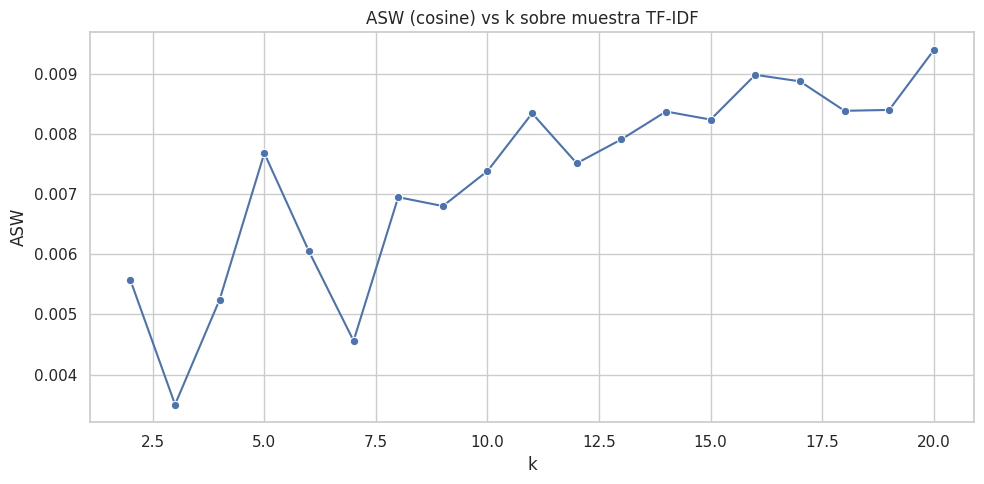

In [12]:
# Heuristica de k con silhouette sobre muestra TF-IDF
sample_n = min(3000, len(df))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), size=sample_n, replace=False)
X_sample = X_tfidf[sample_idx]

k_values = list(range(2, 21))
rows = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    asw = silhouette_score(X_sample, labels, metric="cosine")
    rows.append({"k": k, "asw_cosine": float(asw)})

df_k_scan = pd.DataFrame(rows)
df_k_scan.to_csv(TABLES_DIR / "k_scan_tfidf_cosine_sample.csv", index=False)
display(df_k_scan.head())

ax = sns.lineplot(data=df_k_scan, x="k", y="asw_cosine", marker="o")
ax.set_title("ASW (cosine) vs k sobre muestra TF-IDF")
ax.set_xlabel("k")
ax.set_ylabel("ASW")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "k_scan_tfidf_cosine_sample.png", dpi=180, bbox_inches="tight")
plt.show()

In [13]:
# Subconjunto de 8 categorias tecnicas para topic modeling
TOPIC_LABELS = [
    "comp.graphics",
    "comp.os.ms-windows.misc",
    "comp.sys.ibm.pc.hardware",
    "comp.sys.mac.hardware",
    "comp.windows.x",
    "sci.crypt",
    "sci.electronics",
    "sci.space",
]

available = set(df["label"].unique())
missing = [lbl for lbl in TOPIC_LABELS if lbl not in available]
if missing:
    raise ValueError(f"Categorias no encontradas en 20 Newsgroups: {missing}")

df_subset = df[df["label"].isin(TOPIC_LABELS)].copy().reset_index(drop=True)
subset_counts = df_subset["label"].value_counts().rename_axis("label").reset_index(name="count")

subset_path = TABLES_DIR / "newsgroups20_topic8_subset.csv"
subset_counts_path = TABLES_DIR / "newsgroups20_topic8_subset_label_distribution.csv"
df_subset.to_csv(subset_path, index=False, encoding="utf-8")
subset_counts.to_csv(subset_counts_path, index=False, encoding="utf-8")

print(f"Subset exportado en: {subset_path}")
print(f"Distribucion de labels en: {subset_counts_path}")
print(f"Filas en subset: {len(df_subset)} | labels: {df_subset['label'].nunique()}")
subset_counts

Subset exportado en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_eda/tables/newsgroups20_topic8_subset.csv
Distribucion de labels en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_eda/tables/newsgroups20_topic8_subset_label_distribution.csv
Filas en subset: 7614 | labels: 8


,label,count
0,comp.windows.x,963
1,sci.crypt,962
2,comp.sys.ibm.pc.hardware,959
3,sci.electronics,955
4,sci.space,953
5,comp.graphics,951
6,comp.os.ms-windows.misc,943
7,comp.sys.mac.hardware,928


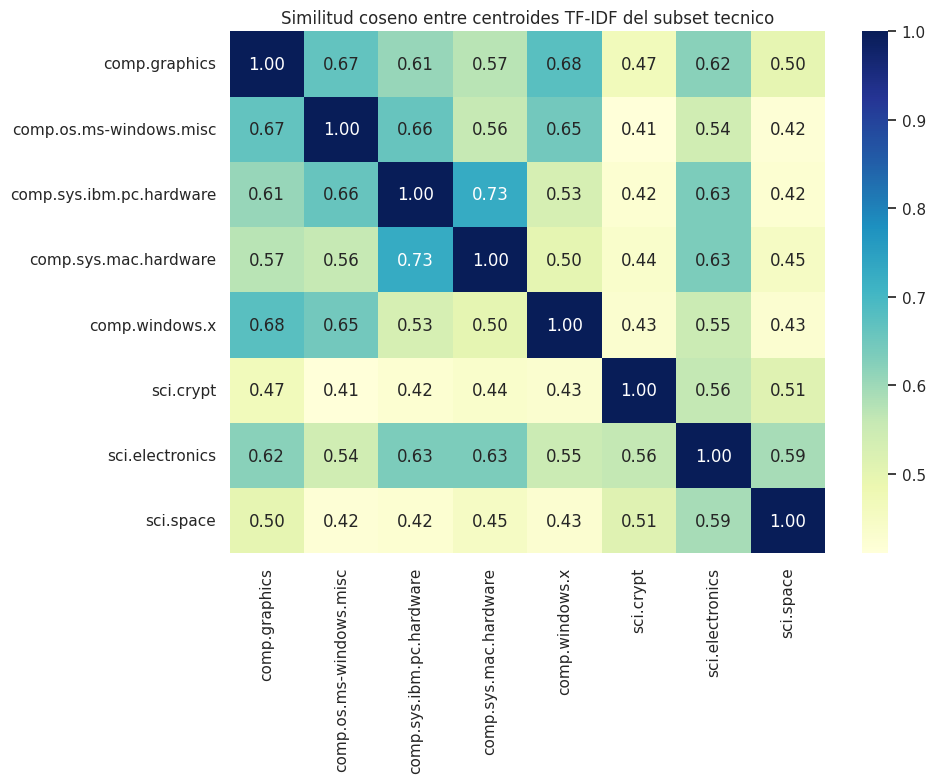

In [14]:
# Similitud entre centroides TF-IDF del subset tecnico
subset_texts = df_subset["text"].tolist()
subset_tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    stop_words="english",
    sublinear_tf=True,
)
X_subset = subset_tfidf.fit_transform(subset_texts)

label_to_rows = {}
for lbl in TOPIC_LABELS:
    idx = np.where(df_subset["label"].values == lbl)[0]
    label_to_rows[lbl] = idx

centroids = []
for lbl in TOPIC_LABELS:
    rows = label_to_rows[lbl]
    centroids.append(np.asarray(X_subset[rows].mean(axis=0)).ravel())

centroids = np.vstack(centroids)
sim = cosine_similarity(centroids)
sim_df = pd.DataFrame(sim, index=TOPIC_LABELS, columns=TOPIC_LABELS)
sim_df.to_csv(TABLES_DIR / "newsgroups20_topic8_centroid_cosine_similarity.csv", encoding="utf-8")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Similitud coseno entre centroides TF-IDF del subset tecnico")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "newsgroups20_topic8_centroid_similarity.png", dpi=180, bbox_inches="tight")
plt.show()

## Resultado principal del EDA

Archivo listo para la fase de topic modeling:
- validation/results/newsgroups20_eda/tables/newsgroups20_topic8_subset.csv

Este subconjunto contiene documentos de 8 categorias tecnicas utiles para validar topic extraction con un escenario realista y parcialmente solapado.